Figuring out the optimal cell size (cs) is the single most important skill a geophysicist can learn in 3D modeling. It is the ultimate tug-of-war between Physics (wanting infinite accuracy) and Computer Science (not wanting your computer to catch fire).While nc (number of cells) is dictated by the massive, invisible Electromagnetic Skin Depth, your cs (cell size) is dictated entirely by the physical geometry of your real-world survey.Here are the three golden rules to finding the perfect, optimal cs.

Rule 1: The "Lego" Rule (Target Resolution)Your mesh is made of 3D Lego bricks. If your target is a 1-meter wide trench, and your cs is 2 meters, your target mathematically doesn't exist—it gets swallowed and volume-averaged into the background earth.

 The Rule of Thumb:
  You need at least 3 to 4 cells to accurately define the smallest physical dimension of your target.The Math: cs = Smallest_Target_Width / 4In your model: Your linear target was 2 meters wide. $2\text{m} / 4 = \mathbf{0.5\text{m}}$. A cs of 0.5m perfectly maps your target without wasting memory. A cs of 0.25m gives you 8 cells across, which is ultra-HD but computationally expensive.

Rule 2: The "Proximity" Rule (Instrument Setup)Electromagnetic fields decay proportionally to $1/r^3$. This means the magnetic field is overwhelmingly violent right next to the transmitter coil, and drops off rapidly. If your cells near the transmitter are too big, the math cannot calculate that steep curve accurately.

The Rule of Thumb:
 Your cell size must be small enough to separate your instrument from any massive geological boundaries (like the Air/Seawater interface).In your model: You were flying at instrument_height = 0.1m. If you use cs = 1.0m, the instrument and the earth are sharing the exact same cell. Because of your low flying height, you were forced into cs = 0.25m or cs = 0.1m to safely isolate the dipole from the water.
 
Rule 3: The "Cube Curse" (The Memory Wall)This is the rule that breaks everyone's code. Because we are modeling in 3D, halving your cell size doesn't double your workload—it multiplies it by 8.If a 0.5m mesh has 100,000 cells.Cutting cs in half to 0.25m will generate 800,000 cells ($2 \times 2 \times 2$).Cutting it again to 0.125m will generate 6.4 Million cells.
 
 The Rule of Thumb: Never use a cell size smaller than absolutely necessary to satisfy Rule 1 and Rule 2.
 
The Professional Workflow: "Grid Convergence"
 If you ever write a paper or report on this, nobody guesses cs. Professionals use a process called a Grid Convergence Test.Here is how you actually find the optimal cs in the real world:Start Chunky: Set cs = 1.0m. Run the model. It will take 10 seconds. Look at the maximum anomaly value (e.g., it reads a 5 mS/m drop).Cut it in Half: Set cs = 0.5m. Run the model. It will take 1 minute. Look at the maximum anomaly value (e.g., it reads a 8 mS/m drop).Cut it in Half Again: Set cs = 0.25m. Run the model. It will take 10 minutes. The anomaly reads a 8.2 mS/m drop.STOP. The difference between 0.5m and 0.25m was only 0.2 mS/m. The physics have "converged." Making the cells any smaller (like 0.125m) might take 5 hours to run, but the answer will still be 8.2 mS/m.Therefore, your optimal cs is the largest cell size that gives you the exact same mathematical answer as the ultra-fine cell size.

Choosing the optimal nc (number of base cells) in a 3D electromagnetic model is a balancing act between the strict rules of computer science and the laws of physics.To find the perfect nc, you have to satisfy three specific rules.

Rule 1: The "Power of 2" (The Computer Science)Because we are using an Octree mesh (TreeMesh), the mesh works by taking a massive root box and recursively cutting it exactly in half. Therefore, nc must always be a power of 2. * Allowed values: 64, 128, 256, 512, 1024, 2048...

Rule 2: The Skin Depth (The Physics)The total width of your mathematical world is defined as cs * nc. This total domain must be large enough to contain your physical survey area plus a massive empty "padding" zone. If the electromagnetic fields hit the edge of your mathematical grid before they have naturally decayed to zero, they will "bounce" off the edge and contaminate your data with fake numerical reflections.We determine how big this padding needs to be using the Electromagnetic Skin Depth:$\delta \approx 503 \sqrt{\rho / f}$Let's calculate this for your specific model:Your background earth is $10\ \Omega\cdot m$.Your DUALEM frequency is $9000$ Hz.$\delta \approx 503 \sqrt{10 / 9000} \approx 16.7\text{ meters}$.The Geophysics Rule of Thumb: Your mathematical boundaries must extend at least 2 to 3 times the skin depth away from the furthest point your instrument travels.Minimum Padding Required: $2 \times 16.7\text{m} = \mathbf{33.4\text{ meters}}$.

Rule 3: Putting it Together to calculate nc
Now we can calculate exactly why nc = 512 was the optimal choice for your 25cm model!

Calculate the Minimum Domain Size:
 Your survey grid spans from X = -20 to X = +20 (A 40m wide footprint).Add the required padding to both sides (33.4m + 33.4m).Minimum Domain Width = 40 + 33.4 + 33.4 = 106.8 meters.

Calculate the Target nc: 
Divide that required width by your cell size (cs = 0.25m).$106.8 / 0.25 = 427.2\text{ cells}$.

Round up to the nearest Power of 2:
The next power of 2 after 427 is 512.

By choosing nc = 512, your actual domain size becomes exactly 128 meters ($512 \times 0.25$). This perfectly houses your 40m survey while providing 44 meters of padding on all sides—safely absorbing the EM fields and preventing boundary reflections.

What happens if you pick the wrong nc?
If nc is too small (e.g., 256): Your total domain is only 64m wide. The 8m coil will practically be touching the outer boundary. The solver will panic, and your plots will show massive, fake anomalies spiking to millions of mS/m at the edges.
If nc is too big (e.g., 2048): In a TensorMesh, this would instantly crash your computer's RAM. 

In a TreeMesh, it's actually relatively safe! Because it only refines where you tell it to, the extra padding is represented by just a few massive 8-meter or 16-meter empty blocks. It won't hurt the math, but it might slow the solver down by a few seconds.Would you like to look at extracting 1D profiles (like line graphs) from the 2D apparent conductivity grid you generated, to see exactly what the DUALEM curve looks like as it crosses directly over the linear target?

Mathematically, they are exactly the same. But in the real world of 3D modeling, TreeMesh is vastly more accurate.Here is the breakdown of why this is the case, and the one specific scenario where a TensorMesh actually beats a TreeMesh.

1. The Math:
 A TieBoth TensorMesh and TreeMesh solve the exact same Finite-Volume Maxwell's equations. If you create a TensorMesh with 25 cm cells and a TreeMesh with 25 cm cells, and place your instrument inside them, the solver will output the exact same numbers. Neither one has a "better" physics engine.
 
 2. The Reality:
  Why TreeMesh Wins 99% of the TimeIn 3D geophysics, accuracy is entirely limited by your computer's RAM. To get highly accurate secondary fields, your cells need to be incredibly small near the transmitter and the targets.The TensorMesh Problem: A TensorMesh is a rectilinear grid. If you tell it you need a 25 cm cell in the middle of your survey, that 25 cm column must extend all the way to the edge of the padding, and all the way down to the core of the earth. You end up calculating millions of 25 cm empty blocks of air and deep earth. Your computer crashes before you can ever achieve high accuracy.The TreeMesh Solution: Because an Octree mesh only splits blocks in half exactly where you tell it to (using refine_bounding_box), you can afford to make cells 5 cm or 10 cm wide right at the DUALEM sensors, while leaving the deep earth as massive 16-meter blocks. TreeMesh is more accurate simply because it allows you to simulate much smaller cells without running out of memory.

3. The Exception:
 When TensorMesh is BetterThere is one specific scenario where TensorMesh is actually superior, and you ran into it earlier: Extreme 1D Layering (like 5 cm instrument heights).In a TreeMesh, when a block splits, it splits equally in all three directions (X, Y, and Z). If you want 5 cm accuracy in the Z-axis to separate your low-flying instrument from the water, you are forced to also have 5 cm accuracy in X and Y. That creates a massive amount of cells.A TensorMesh allows for extreme anisotropy (squashed cells).You can design a TensorMesh where the cells are 2 meters wide in X and Y, but a razor-thin 2 cm tall in the Z-axis right at the surface. This perfectly separates your 5 cm instrument from the $0.3\ \Omega\cdot m$ seawater boundary with ultimate precision, while keeping the cell count incredibly low.

Summary
Use TreeMesh when you have complex 3D targets (like buried blocks, dipping layers, or localized topography) and you need to fly surveys over them. It optimizes memory so you can get high resolution around the 3D shapes.Use TensorMesh when your world is mostly flat horizontal layers (like the ocean) and you need extreme vertical precision (like flying an instrument 5 cm off the ground), but you don't care about having high X/Y resolution.

the 8m HCP plot, the background is around 300 mS/m, and the target only drops it to about 236 mS/m.

This is not a bug in your code. This is a perfect demonstration of the brutal reality of real-world electromagnetic geophysics. You have run right into three fundamental physical limitations of EMI surveying:

1. The Seawater "Blanket"
You have a 0.5-meter layer of highly conductive seawater (0.3 Ω⋅m, or roughly 3,333 mS/m) sitting right on top of your model.
Because it is so conductive, it absorbs almost all of the primary magnetic energy from your transmitter. By the time the electromagnetic field penetrates the water and reaches your target at 1.5 meters depth, the field is extremely weak. The receiver coils are completely blinded by the massive secondary field generated by the seawater, masking the subtle changes happening below.

2. EMI Hates Resistive Targets
Electromagnetic induction works by creating eddy currents in the ground. Conductive targets (like buried metal, clay, or saltwater) easily support massive eddy currents, creating a loud, easily detectable signal.
Your target is resistive (100 Ω⋅m, or 10 mS/m). Resistive targets do not generate eddy currents. The only way an EMI instrument "sees" a resistive target is by noticing an absence of the expected background signal. Because you are only detecting an absence of current, the anomaly will always be weak.

3. Massive Volume Averaging
An 8-meter DUALEM coil doesn't measure a tight, laser-focused point. It measures a massive, 3D bulbous volume of earth extending several meters down and out to the sides.
When the instrument is directly over your target, the volume it is averaging consists of:

A massive amount of 3,333 mS/m seawater.

A massive amount of 100 mS/m background earth.

A tiny sliver of your 10 mS/m target.
Because your 2-meter wide target only makes up a tiny percentage of the total volume the instrument is looking at, it can only drag the overall average down by a few mS/m.

Proof that your model is working perfectly:
Look at the overall scales of your three HCP plots:

2m HCP: The values are hovering around ~3550 mS/m. The 2m coil has a very shallow depth of penetration. It is almost exclusively "seeing" the 3,333 mS/m seawater layer.

4m HCP: The values drop to ~1940 mS/m. The 4m coil sees deeper, averaging the seawater and the 100 mS/m background earth beneath it.

8m HCP: The values plummet to ~280 mS/m. The 8m coil sees very deep! It is completely piercing the seawater layer and looking deep into the resistive earth. Because it sees the deepest, it also has the strongest contrast (drop) when it crosses over your target.

Want to see the contrast pop? If you want to prove the physics to yourself, we can easily change one variable. Would you like to change the target from a resistive trench (100 Ω⋅m) to a highly conductive clay trench (1 Ω⋅m) to see how much louder a conductive target is, or would you like to "drain" the seawater out of the model entirely?

Geometric Coupling and the Instrument Footprint.

What you are seeing is not a glitch in the simulation. It is the exact physical reality of dragging an 8-meter-long instrument over a narrow target.

Here is exactly why the 8m anomaly looks so massive and has that distinct "dipole" or "lobed" shape compared to the 2m coils.

1. Why it looks so WIDE: The "Footprint" Effect
Imagine trying to guess the shape of a rock by stepping on it. If you wear a thin ballet shoe (the 2m coil), you feel the sharp edges exactly where they are. If you wear a massive, rigid snowshoe (the 8m coil), the "bump" feels much wider and less defined.

In EMI instruments, the volume of earth being measured is directly tied to the separation between the Transmitter (Tx) and the Receiver (Rx).

When the 8m instrument is towed across your 2-meter-wide target, the Tx detects the target first.

As you keep walking, the Tx passes the target, but the Rx is 8 meters behind you, so the instrument is still feeling it.

The instrument will register the anomaly for the entire time either coil is near the target. Therefore, a 2-meter target gets artificially stretched or "smeared" into an anomaly that is at least 10 to 12 meters wide on your map!

2. Why it has a "Dipole Form": Geometric Coupling
This is the most critical concept in processing DUALEM data. An EMI instrument doesn't just output a single "blip" when it goes over a target. Because the magnetic fields are curved, the angle at which those fields hit the target changes as the instrument moves.

The PRP "Cross-Over" (The True Dipole): Look at your bottom row (PRP App. Cond.). The PRP receiver coil is oriented perpendicularly. As the transmitter approaches the linear target, the curved magnetic field hits the target from the left, creating an artificial "high" reading. As the instrument crosses dead-center, the field perfectly cancels out (reading normal). As it moves away, the field hits the target from the right, creating an artificial "low" reading. This creates an anti-symmetric shape (a positive lobe right next to a negative lobe) that looks exactly like a dipole!

The HCP "Shoulder" Effect: Look at your top row (HCP App. Cond.). The HCP coils are horizontal. When they cross a narrow linear target, they create an "M" or "W" shape anomaly in 1D. You get a central reading directly over the target, flanked by two "overshoot" side-lobes of the opposite value. Because the coils are 8 meters apart, those side-lobes are physically pushed 8 meters apart on your map, creating that massive, wide, banded look.

Summary
You are seeing a tiny 2-meter target convolved with an 8-meter measuring stick. The "dipole" shape is just the physical signature of the curved magnetic fields twisting through the target as the long instrument drags over it.

Geophysicists actually use the distance between those "dipole lobes" to calculate the exact depth of the target!

If you want to see this geometrically without the distraction of the 2D map blurring it together, we could write a quick script to extract a single 1D line directly across X=0. When you look at it as a line graph, the "M" shapes and "Cross-overs" become perfectly obvious. Let me know if you want to see that!

1. Building TreeMesh...
   Mesh successfully built with 626,116 cells.
2. Assigning resistivities...
3. Setting up 2D Grid survey...
4. Running 3D simulation for 121 stations (Grab a coffee)...


/var/folders/qk/kyt4tfjs7ydd5mb2bk8dn_f00000gn/T/ipykernel_11361/526053834.py:23: FutureWarning: In discretize v1.0 the TreeMesh will change the default value of diagonal_balance to True, which will likely slightly change meshes you have previously created. If you need to keep the current behavior, explicitly set diagonal_balance=False.
  mesh = discretize.TreeMesh([[(cs, nc)], [(cs, nc)], [(cs, nc)]], x0="CCC")
/opt/anaconda3/envs/pgy/lib/python3.12/site-packages/simpeg/base/pde_simulation.py:490: DefaultSolverWarning: Using the default solver: Mumps. 

If you would like to suppress this notification, add 
warnings.filterwarnings('ignore', simpeg.utils.solver_utils.DefaultSolverWarning)
 to your script.
  return get_default_solver(warn=True)


5. Processing Data using Stable LIN Approximation...
6. Generating 2D surface maps...


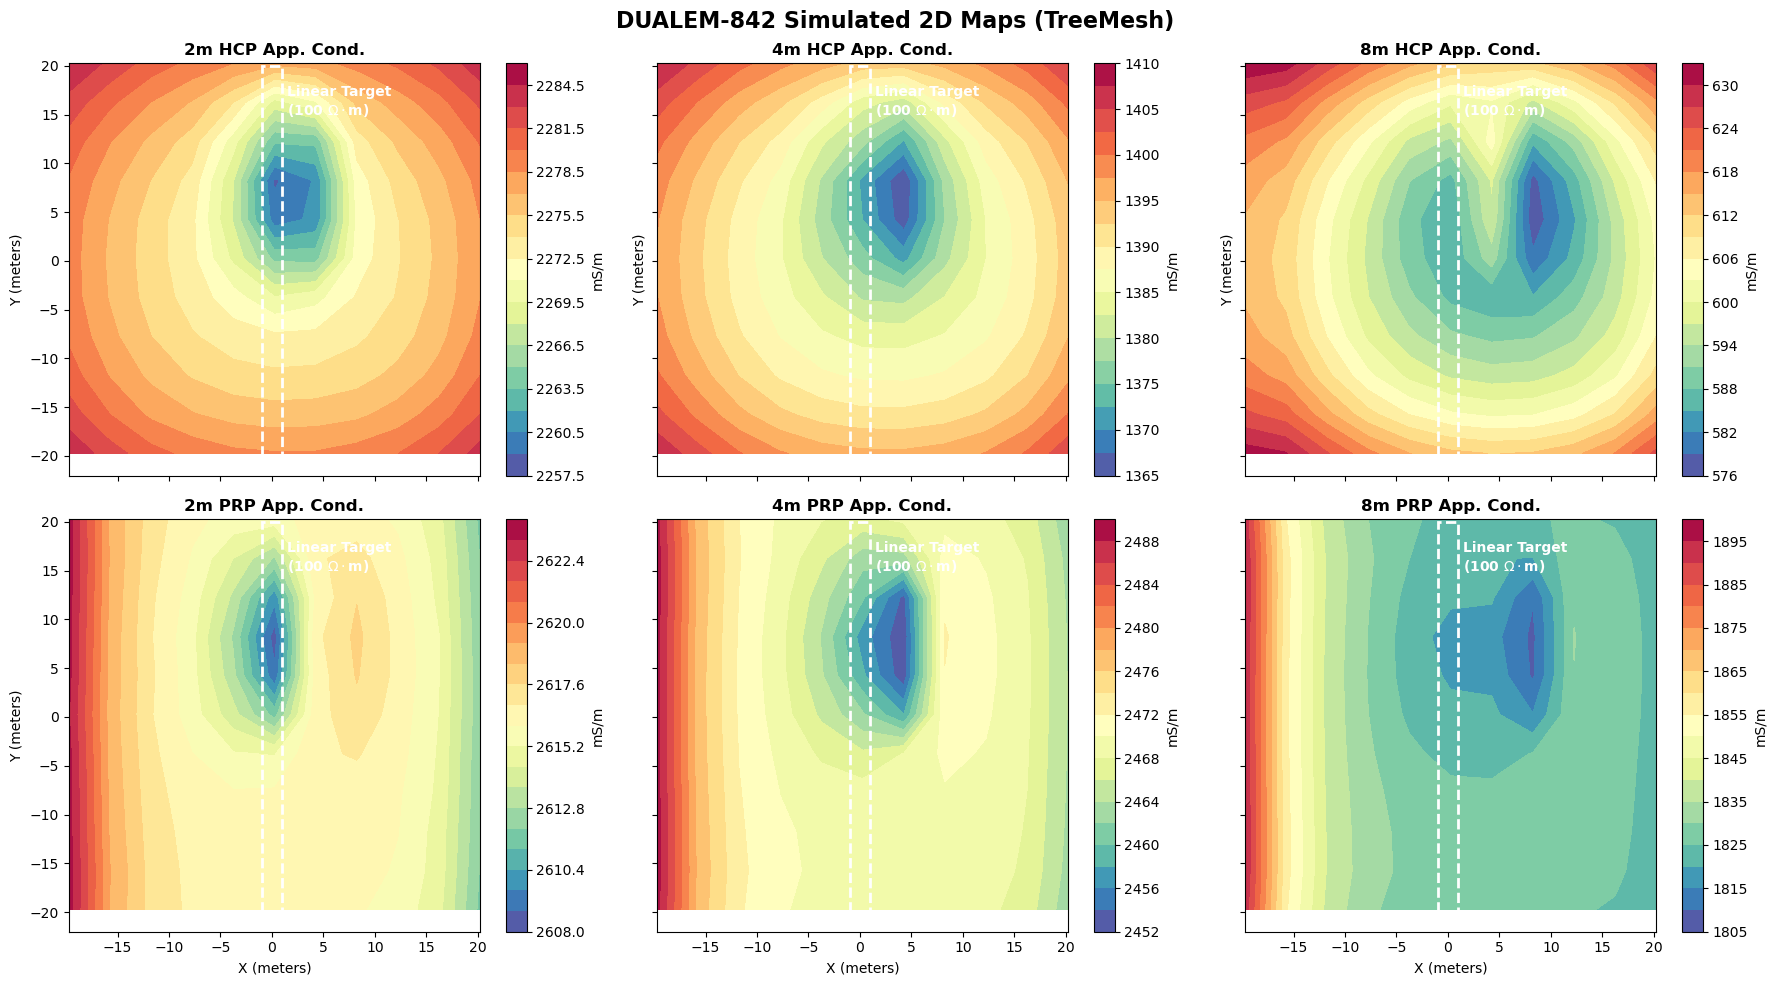

In [2]:
import numpy as np
import discretize
from SimPEG import maps
from SimPEG.electromagnetics import frequency_domain as fd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.constants as const

# =========================================================
# 0. THE TOGGLE SWITCH
# =========================================================
# Change this variable to either "TreeMesh" or "TensorMesh"
MESH_TYPE = "TreeMesh"  
fac = 2  # Adjust this factor to speed up (fac=2) or increase accuracy (fac=1)
# =========================================================
# 1. Create the Mesh (Based on your selection)
# =========================================================
print(f"1. Building {MESH_TYPE}...")
cs = fac * 0.25  # 25cm core cells

if MESH_TYPE == "TreeMesh":
    nc = 512 / fac  
    mesh = discretize.TreeMesh([[(cs, nc)], [(cs, nc)], [(cs, nc)]], x0="CCC")
    
    # Refine the core ROI and the surface
    roi_points = np.array([[-40.0, -40.0, -8.0], [40.0, 40.0, 0.0]])
    mesh.refine_bounding_box(roi_points, level=-1, padding_cells_by_level=[0, 3, 3])
    
    surface_points = np.array([[-42.0, -42.0, -1.0], [42.0, 42.0, 0.5]])
    mesh.refine_bounding_box(surface_points, level=-1, padding_cells_by_level=[3, 2, 2])

elif MESH_TYPE == "TensorMesh":
    print("   WARNING: TensorMesh will generate >3 Million cells. This will take time!")
    # Core domain: 50m wide in X and Y (200 cells), 10m deep in Z (40 cells)
    # Padding: Expanding outward by a factor of 1.3 to push boundaries away
    npad = 12
    hx = [(cs, npad, -1.3), (cs, 200), (cs, npad, 1.3)]
    hy = [(cs, npad, -1.3), (cs, 200), (cs, npad, 1.3)]
    hz = [(cs, 15, -1.3), (cs, 40), (cs, 10, 1.3)]
    
    mesh = discretize.TensorMesh([hx, hy, hz], x0="CCC")

print(f"   Mesh successfully built with {mesh.nC:,} cells.")

# =========================================================
# 2. Define the Custom 3D Model
# =========================================================
print("2. Assigning resistivities...")
x = mesh.cell_centers[:, 0]
y = mesh.cell_centers[:, 1]
z = mesh.cell_centers[:, 2]

# Define Resistivities (Ohm-meters)
res_air = 1e8
res_seawater = 0.3     # Highly conductive seawater
res_background = 10.0  # Homogeneous background (10 Ohm-m)
res_linear = 100.0     # Resistive linear target (100 Ohm-m)

sig_model = np.ones(mesh.nC) * (1.0 / res_air)

# A. Background Earth (10 Ohm-m everywhere below Z=0)
earth_indices = z < 0
sig_model[earth_indices] = 1.0 / res_background

# B. Seawater Layer (0.3 Ohm-m from Z=0 to Z=-0.5m)
seawater_indices = (z <= 0) & (z > -0.5)
sig_model[seawater_indices] = 1.0 / res_seawater

# C. Linear Target (100 Ohm-m, 2m wide, running along Y-axis)
linear_target_indices = (x > -1.0) & (x < 1.0) & (y > .0) & (y < 15.0) & (z > -4.0) & (z < -1.5)
sig_model[linear_target_indices] = 1.0 / res_linear

# =========================================================
# 3. Setup the 2D Grid Survey (DUALEM-842)
# =========================================================
print("3. Setting up 2D Grid survey...")
frequency = 9000.0
instrument_height = 0.1 

nx, ny = 11, 11
# Shift by 0.125m so coils sit perfectly in the center of the 0.25m cells
shift = cs / 2
xr = np.linspace(-20, 20, nx) + shift
yr = np.linspace(-20, 20, ny) + shift
X_grid, Y_grid = np.meshgrid(xr, yr)

stations = np.c_[X_grid.ravel(), Y_grid.ravel()]
n_stations = len(stations)
boom_vector = np.array([1.0, 0.0, 0.0]) 
offsets = [2.0, 4.0, 8.0]
source_list = []

for stat in stations:
    tx_loc = np.array([stat[0], stat[1], instrument_height])
    rx_locs = np.array([tx_loc - d * boom_vector for d in offsets])
    
    rx_hcp_r = fd.receivers.PointMagneticField(locations=rx_locs, orientation="z", component="real")
    rx_hcp_i = fd.receivers.PointMagneticField(locations=rx_locs, orientation="z", component="imag")
    
    rx_prp_r = fd.receivers.PointMagneticField(locations=rx_locs, orientation=boom_vector, component="real")
    rx_prp_i = fd.receivers.PointMagneticField(locations=rx_locs, orientation=boom_vector, component="imag")
    
    tx = fd.sources.MagDipole(
        receiver_list=[rx_hcp_r, rx_hcp_i, rx_prp_r, rx_prp_i],
        location=tx_loc, orientation="z", frequency=frequency
    )
    source_list.append(tx)

survey = fd.Survey(source_list)

# =========================================================
# 4. Run the 3D Forward Simulation
# =========================================================
print(f"4. Running 3D simulation for {n_stations} stations (Grab a coffee)...")
model_mapping = maps.IdentityMap(mesh)
simulation = fd.Simulation3DMagneticField(mesh, survey=survey, sigmaMap=model_mapping)

dpred = simulation.dpred(sig_model)

# =========================================================
# 5. Process Data: Stable McNeill LIN Math
# =========================================================
print("5. Processing Data using Stable LIN Approximation...")
data_matrix = dpred.reshape((n_stations, 12))

omega = 2 * np.pi * frequency
mu_0 = const.mu_0

sigma_a_hcp = np.zeros((n_stations, 3))
sigma_a_prp = np.zeros((n_stations, 3))

for i, s in enumerate(offsets):
    Hp = 1.0 / (4 * np.pi * s**3)
    
    H_imag_hcp = np.abs(data_matrix[:, 3 + i]) 
    H_imag_prp = np.abs(data_matrix[:, 9 + i]) 
    
    # Standard McNeill conversion to apparent conductivity (mS/m)
    sigma_a_hcp[:, i] = ((4.0 / (omega * mu_0 * s**2)) * (H_imag_hcp / Hp)) * 1000.0
    sigma_a_prp[:, i] = ((4.0 / (omega * mu_0 * s**2)) * (H_imag_prp / Hp)) * 1000.0

hcp_grids = [sigma_a_hcp[:, i].reshape((ny, nx)) for i in range(3)]
prp_grids = [sigma_a_prp[:, i].reshape((ny, nx)) for i in range(3)]

# =========================================================
# 6. Plotting the 2D Maps with Target Outlines
# =========================================================
print("6. Generating 2D surface maps...")
fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)

titles_hcp = ['2m HCP App. Cond.', '4m HCP App. Cond.', '8m HCP App. Cond.']
titles_prp = ['2m PRP App. Cond.', '4m PRP App. Cond.', '8m PRP App. Cond.']

def add_target_outlines(ax):
    # Draw the linear target (2m wide, spanning the Y-axis)
    rect = patches.Rectangle((-1, -20), 2, 40, linewidth=2, edgecolor='white', facecolor='none', linestyle='--')
    ax.add_patch(rect)
    ax.text(1.5, 15, "Linear Target\n(100 $\Omega\cdot$m)", color='white', fontweight='bold')

for i in range(3):
    ax = axs[0, i]
    cf = ax.contourf(X_grid, Y_grid, hcp_grids[i], levels=20, cmap='Spectral_r')
    ax.set_title(titles_hcp[i], fontweight='bold')
    ax.set_ylabel('Y (meters)')
    add_target_outlines(ax)
    fig.colorbar(cf, ax=ax, label="mS/m")

for i in range(3):
    ax = axs[1, i]
    cf = ax.contourf(X_grid, Y_grid, prp_grids[i], levels=20, cmap='Spectral_r')
    ax.set_title(titles_prp[i], fontweight='bold')
    ax.set_xlabel('X (meters)')
    if i == 0: ax.set_ylabel('Y (meters)')
    add_target_outlines(ax)
    fig.colorbar(cf, ax=ax, label="mS/m")

plt.suptitle(f"DUALEM-842 Simulated 2D Maps ({MESH_TYPE})", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()